# Nuclear Segmentation Benchmark

This notebook wraps `benchmark_nuclear_segmentation.py` for interactive runs.

Workflow:

1. Update the batch configuration cell.
2. Add one entry per model you want to compare.
3. Run the benchmark cell once.
4. One CSV is written per model, and the summary plot updates from all CSV files in `model_benchmarking/results/`.

> Note: The Cellpose cyto3 and nuclei models need Cellpose v3 to run and are not compatible with the v4 version that has the SAM model. If you want to run cyto3 and nuclei, you need to install Cellpose v3 in a separate environment. You can also run the v3 models in a separate run and then include the resulting CSV files in the summary plot step.


In [1]:
from pathlib import Path
import sys

import numpy as np
from skimage import measure
from tqdm import tqdm

from IPython.display import Image as NotebookImage, display

try:
    import pandas as pd
except ImportError:
    pd = None

cwd = Path.cwd().resolve()
if cwd.name == "model_benchmarking":
    repo_root = cwd.parent
else:
    repo_root = cwd

benchmark_root = repo_root / "model_benchmarking"
if not benchmark_root.exists():
    raise FileNotFoundError(
        f"Could not find model_benchmarking under {repo_root}. Start Jupyter from the repo root or the model_benchmarking folder."
    )

if str(benchmark_root) not in sys.path:
    sys.path.insert(0, str(benchmark_root))

from benchmark_nuclear_segmentation import run_benchmark, write_csv, write_summary_plot

benchmark_root


c:\Users\yukan\anaconda3\envs\cellpose3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('C:/Users/yukan/SynologyDrive/WS01 Sync/Windows Desktop/senoquant-dev/model_benchmarking')

In [2]:
# Batch configuration

model_specs = [
    # {
    #     "name": "default_2d",
    #     "models_root": None,
    #     "settings": {
    #         "object_diameter_px": 16.18, # Mean nuclear diameter of the TissueNet testing set
    #         "prob_thresh": 0.496187,
    #         "nms_thresh": 0.3,
    #     },
    # },
    # {
    #     "name": "cpsam",
    #     "models_root": None,
    #     "settings": {
    #         "diameter": 16.18,
    #         "flow_threshold": 0.4,
    #         "cellprob_threshold": 0.0,
    #         "n_iterations": 0,
    #     },
    # },
    # {
    #     "name": "cp_cyto3",
    #     "models_root": benchmark_root / "models",
    #     "settings": {
    #         "diameter": 16.18,
    #         "flow_threshold": 0.4,
    #         "cellprob_threshold": 0.0,
    #         "n_iterations": 0,
    #     },
    # },
#     {
#     "name": "cp_nuclei",
#     "models_root": benchmark_root / "models",
#     "settings": {
#         "diameter": 16.18,
#         "flow_threshold": 0.4,
#         "cellprob_threshold": 0.0,
#         "n_iterations": 0,
#     },
# },
]

images_dir = benchmark_root / "images"
ground_truth_dir = benchmark_root / "ground_truth"
plot_path = benchmark_root / "results" / "benchmark_summary.png"
plot_title = "TissueNet"

print("Models:")
for spec in model_specs:
    print(f"  - {spec['name']}")
print(f"Images: {images_dir}")
print(f"Ground truth: {ground_truth_dir}")
print(f"Plot output: {plot_path}")


Models:
Images: C:\Users\yukan\SynologyDrive\WS01 Sync\Windows Desktop\senoquant-dev\model_benchmarking\images
Ground truth: C:\Users\yukan\SynologyDrive\WS01 Sync\Windows Desktop\senoquant-dev\model_benchmarking\ground_truth
Plot output: C:\Users\yukan\SynologyDrive\WS01 Sync\Windows Desktop\senoquant-dev\model_benchmarking\results\benchmark_summary.png


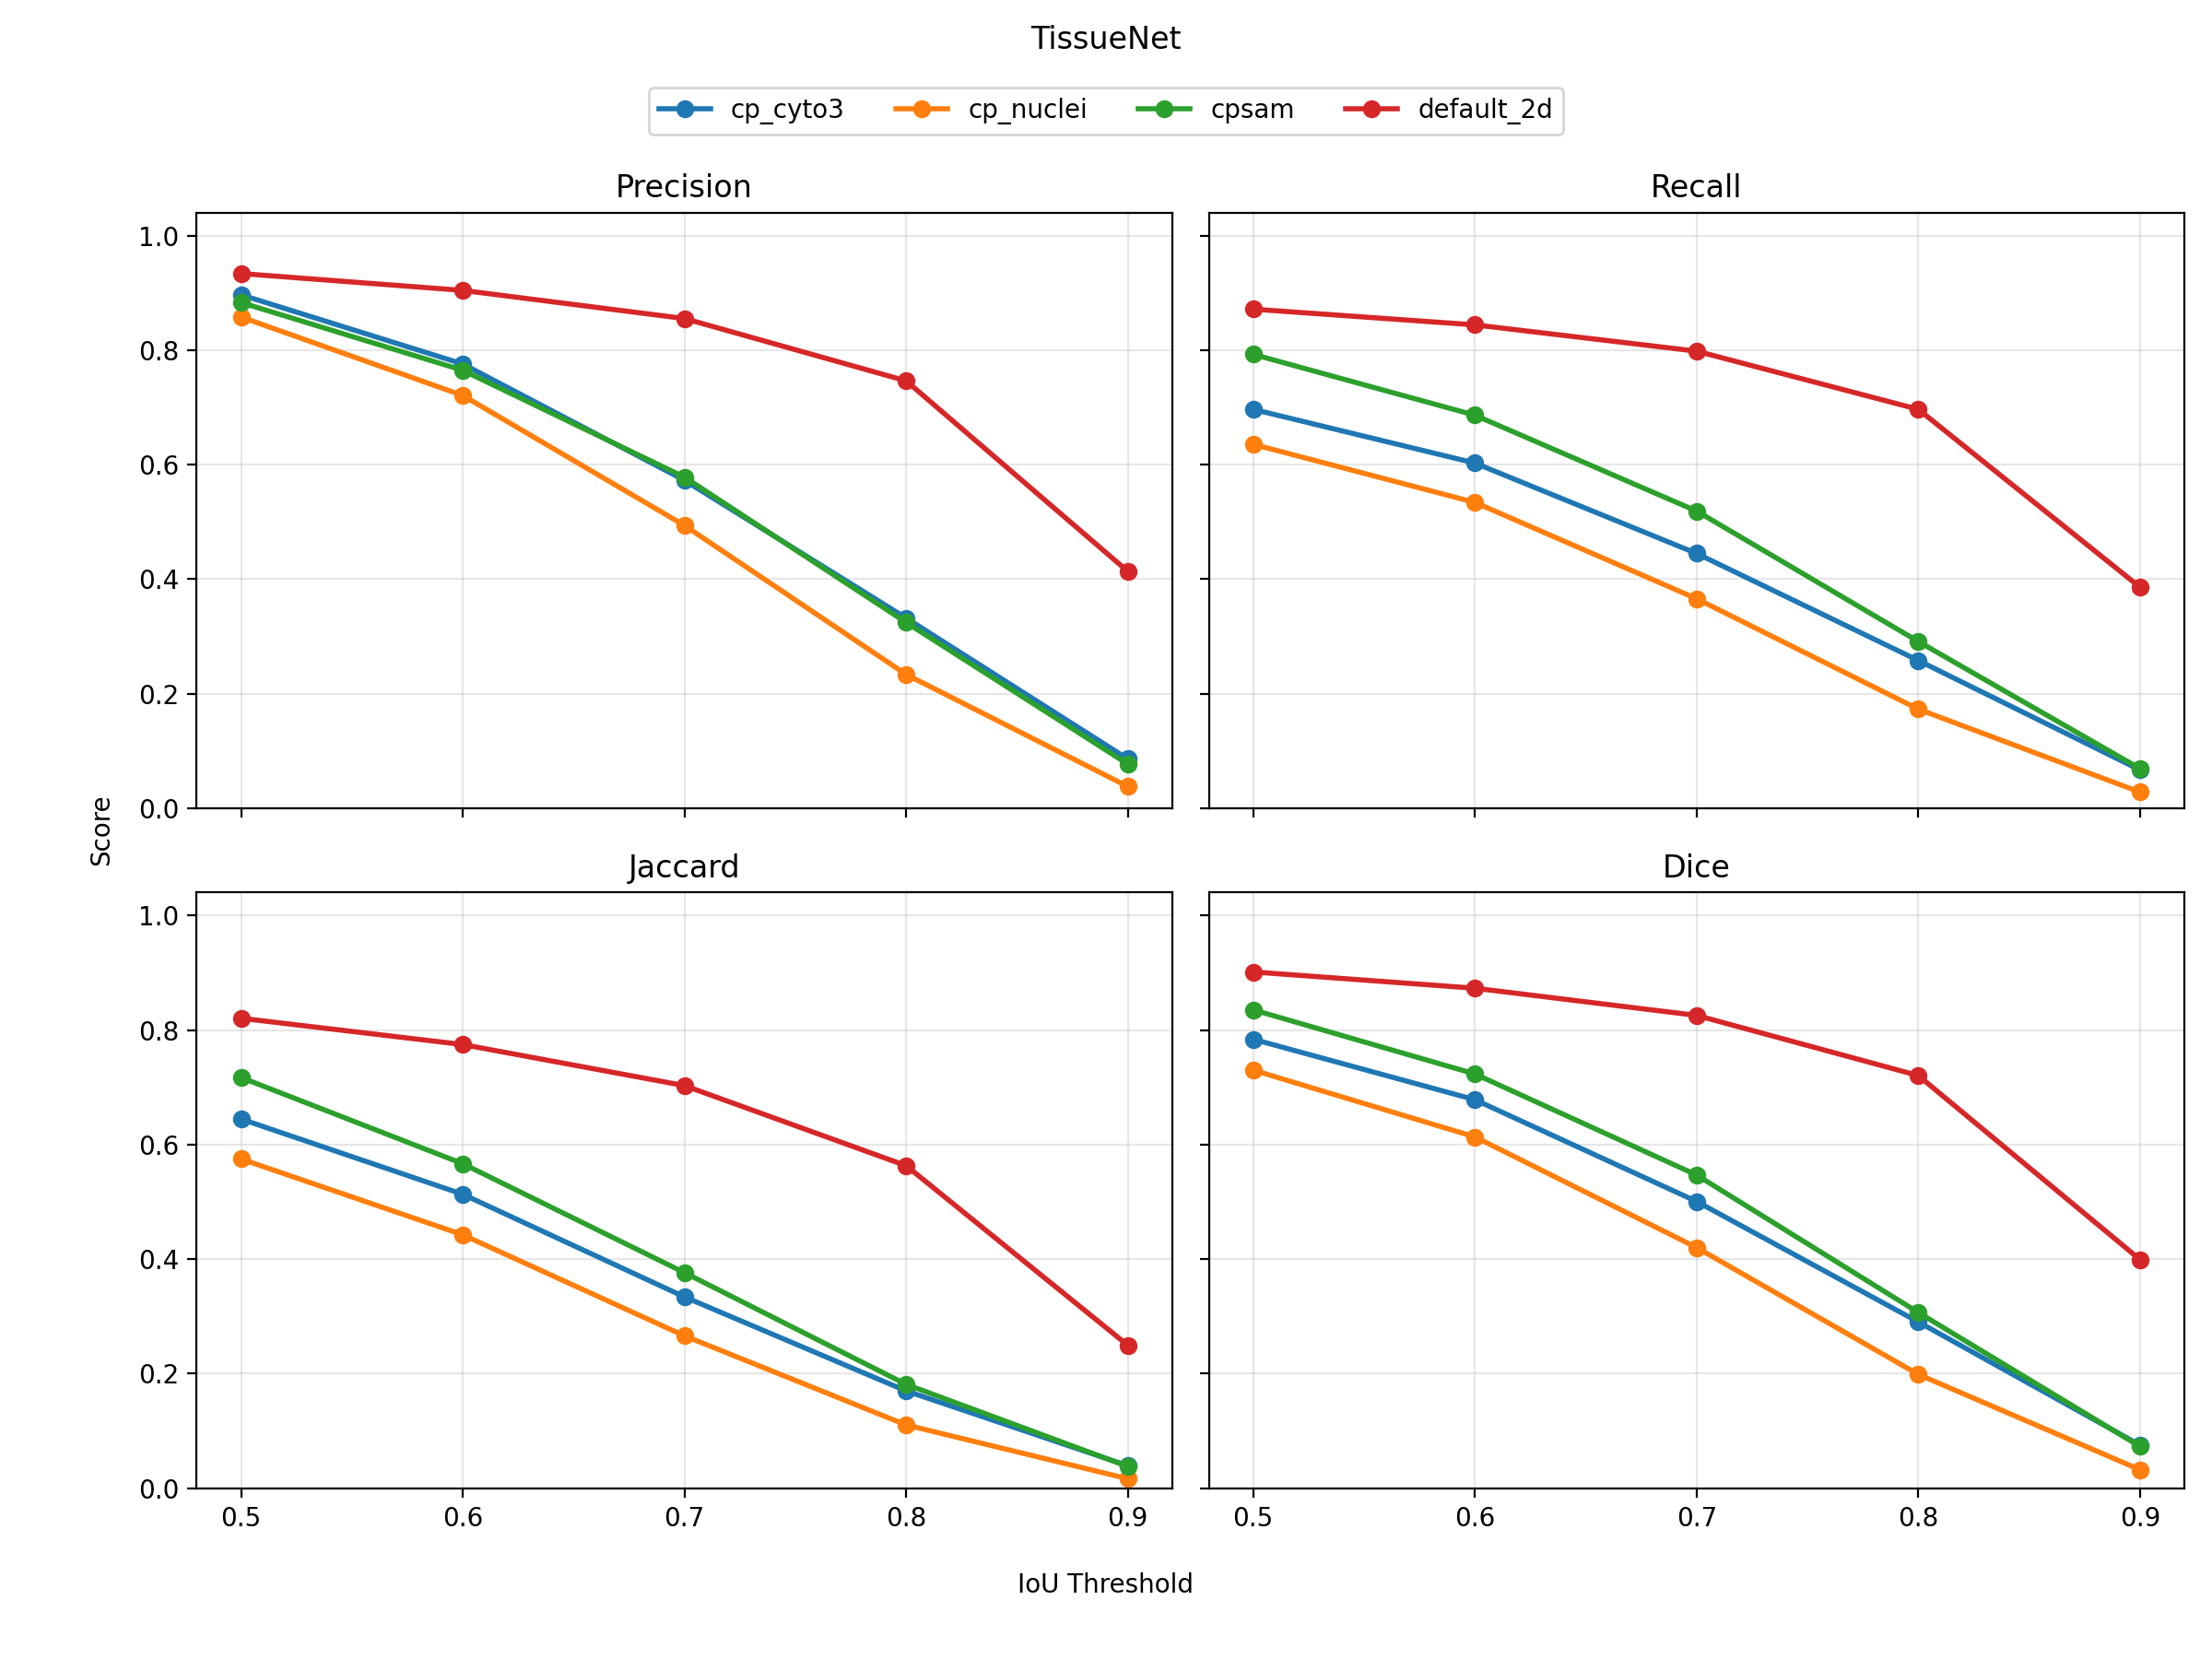

Wrote C:\Users\yukan\SynologyDrive\WS01 Sync\Windows Desktop\senoquant-dev\model_benchmarking\results\benchmark_summary.png


In [3]:
# Benchmark

all_results = {}

for spec in model_specs:
    model_name = spec["name"]
    models_root = spec.get("models_root")
    settings = spec.get("settings", {})
    output_csv = benchmark_root / "results" / f"{model_name}.csv"

    rows = run_benchmark(
        model_name=model_name,
        images_dir=images_dir,
        ground_truth_dir=ground_truth_dir,
        settings=settings,
        models_root=models_root,
    )
    write_csv(output_csv, rows)
    all_results[model_name] = rows
    print(f"Wrote {output_csv}")

write_summary_plot(
    csv_dir=benchmark_root / "results",
    plot_path=plot_path,
    title=plot_title,
)

display(NotebookImage(filename=str(plot_path)))
print(f"Wrote {plot_path}")
